# Random Forest Classifier on SMILES ChemNet Embeddings

### Basic Preprocessing

In [2]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

In [3]:
# The 5/20 dataset with rat based toxicity data
df2 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data2.csv")
print(df2.shape)
df2.head() 

(3068, 12)


,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0067:0.816052 65.0145:5.320549 66.0098:18....,'negative','LC-ESI-QFT','90','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
1,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0066:0.313715 65.0145:2.298303 66.0098:3.8...,'negative','LC-ESI-QFT','75','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
2,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0065:0.181194 65.0145:0.527326 66.0097:0.6...,'negative','LC-ESI-QFT','60','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
3,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0065:0.132092 65.0145:0.255012 69.0346:0.6...,'negative','LC-ESI-QFT','45','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
4,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','69.0346:0.347949 92.0255:0.566186 106.0284:0....,'negative','LC-ESI-QFT','30','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'


In [4]:
# Uniformity of ionization model labels
print(df2["Ionization_Mode"].unique())
df2["Ionization_Mode"] = df2["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df2["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df2 = df2[df2["Ionization_Mode"] != "'N/A'"]
print(df2["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df2
df2 = df2.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df2["SMILES_spectra"] = df2["SMILES_spectra"].str.replace("'", "")
df2.head()

["'negative'" "'positive'" "'Positive'" "'N/A'"]
["'negative'" "'positive'" "'N/A'"]
["'negative'" "'positive'"]


/tmp/ipykernel_7106/106599574.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2 = df2.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)


,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0067:0.816052 65.0145:5.320549 66.0098:18.7...,negative,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
1,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0066:0.313715 65.0145:2.298303 66.0098:3.87...,negative,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
2,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.181194 65.0145:0.527326 66.0097:0.68...,negative,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.132092 65.0145:0.255012 69.0346:0.65...,negative,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,69.0346:0.347949 92.0255:0.566186 106.0284:0.2...,negative,LC-ESI-QFT,30,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg


In [5]:
# Count unique SMILES in the DataFrame
unique_smiles_count = df2["SMILES_spectra"].nunique()
# Count how many SMILES have more than 20, 10, and 5 corresponding rows
smiles_counts = df2["SMILES_spectra"].value_counts()
more_than_20 = (smiles_counts > 20).sum()
more_than_10 = (smiles_counts > 10).sum()
more_than_5 = (smiles_counts > 5).sum()
more_than_1 = (smiles_counts > 1).sum()
just_1 = (smiles_counts == 1).sum()

# Print the results
print("Number of unique SMILES:", unique_smiles_count)
print("SMILES with >20 rows:", more_than_20)
print("SMILES with >10 rows:", more_than_10)
print("SMILES with >5 rows:", more_than_5)
print("SMILES with >1 rows:", more_than_1)
print("SMILES with 1 row:", just_1)



Number of unique SMILES: 347
SMILES with >20 rows: 21
SMILES with >10 rows: 94
SMILES with >5 rows: 247
SMILES with >1 rows: 331
SMILES with 1 row: 16


### Save ChemNet Dataframe for 5/20 dataset

In [6]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [7]:
# Get the ChemNet embeddings for the SMILES in df2
ChemNet_df2_dict = get_chemnet_emb_from_smiles(df2["SMILES_spectra"].tolist())


In [8]:
# Convert the dictionary to a DataFrame
ChemNet_df2 = pd.DataFrame.from_dict(ChemNet_df2_dict, orient='index')
# Name the first column to "SMILES" and check the dataframe
ChemNet_df2.reset_index(inplace=True)
ChemNet_df2.rename(columns={'index': 'SMILES'}, inplace=True)
ChemNet_df2.head()

,SMILES,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343482,0.000665,0.109499,0.623263,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,...,0.001494,-0.356038,0.435746,-1.227338e-03,0.135887,0.161948,0.331081,0.624193,0.150636,0.398498
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178222,0.005417,0.428078,0.479779,-0.162643,0.033273,-0.322552,-0.034872,-0.049524,...,0.002964,0.204067,0.215919,-1.736634e-02,0.542050,0.477725,-0.102496,0.484721,0.349643,-0.029105
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340481,0.000491,-0.096004,0.602170,-0.004242,0.101546,0.200854,-0.061073,-0.239672,...,0.034536,-0.191668,0.951767,8.522559e-07,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172702,0.001335,0.185513,0.693629,-0.003302,0.163642,0.365007,-0.086594,-0.362258,...,0.001197,0.117893,0.938234,-2.608280e-03,-0.428588,-0.166437,-0.151611,0.001681,0.223602,0.140628
4,C1CCC(CC1)NC1CCCCC1,-0.162978,-0.001073,-0.013247,0.099287,-0.102373,0.188363,-0.263953,-0.093572,-0.099310,...,0.140529,-0.014864,0.105941,1.399553e-04,-0.309665,-0.002644,0.028003,-0.137561,0.018753,-0.080631


In [9]:
# Save the ChemNet embeddings to a CSV file
# ChemNet_df2.to_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_df2.csv", index=False)

In [10]:
# Read in the csv file with the ChemNet embeddings
ChemNet_df2 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/ChemNet_df2.csv")
ChemNet_df2.head()

,SMILES,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343482,0.000665,0.109499,0.623263,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,...,0.001494,-0.356038,0.435746,-1.227338e-03,0.135887,0.161948,0.331081,0.624193,0.150636,0.398498
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178222,0.005417,0.428078,0.479779,-0.162643,0.033273,-0.322552,-0.034872,-0.049524,...,0.002964,0.204067,0.215919,-1.736634e-02,0.542050,0.477725,-0.102496,0.484721,0.349643,-0.029105
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340481,0.000491,-0.096004,0.602170,-0.004242,0.101546,0.200854,-0.061073,-0.239672,...,0.034536,-0.191668,0.951767,8.522559e-07,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172702,0.001335,0.185513,0.693629,-0.003302,0.163642,0.365007,-0.086594,-0.362258,...,0.001197,0.117893,0.938234,-2.608280e-03,-0.428588,-0.166437,-0.151611,0.001681,0.223602,0.140628
4,C1CCC(CC1)NC1CCCCC1,-0.162978,-0.001073,-0.013247,0.099287,-0.102373,0.188363,-0.263953,-0.093572,-0.099310,...,0.140529,-0.014864,0.105941,1.399553e-04,-0.309665,-0.002644,0.028003,-0.137561,0.018753,-0.080631


In [11]:
df2.head(10)

,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0067:0.816052 65.0145:5.320549 66.0098:18.7...,negative,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
1,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0066:0.313715 65.0145:2.298303 66.0098:3.87...,negative,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
2,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.181194 65.0145:0.527326 66.0097:0.68...,negative,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.132092 65.0145:0.255012 69.0346:0.65...,negative,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,69.0346:0.347949 92.0255:0.566186 106.0284:0.2...,negative,LC-ESI-QFT,30,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
5,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,92.0254:0.109265 107.0364:0.152054 117.0202:0....,negative,LC-ESI-QFT,15,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
6,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:30.075814 67.0291:0.287672 70.0651:0.2...,positive,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
7,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:14.145079 70.0651:0.238628 80.0495:0.1...,positive,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
8,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:5.979920 70.0652:0.132712 81.0335:100....,positive,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
9,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:2.110021 81.0334:100.000000 119.0352:0...,positive,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg


In [12]:
# Append the response column to the ChemNet DataFrame
# First remove all redundant SMILES from df2
df2_unique_smiles = df2.drop_duplicates(subset=["SMILES_spectra"])
# Merge Response from df2_unique_smiles onto ChemNet_df2 by matching SMILES columns
ChemNet_df2_withtox = ChemNet_df2.merge(
    df2_unique_smiles[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)

# Optionally, drop the now-redundant 'SMILES_spectra' column
ChemNet_df2_withtox.drop(columns=['SMILES_spectra'], inplace=True)


In [13]:
print(ChemNet_df2_withtox.shape)
ChemNet_df2_withtox.head()

(347, 514)


,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343482,0.000665,0.109499,0.623263,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,...,-0.356038,0.435746,-1.227338e-03,0.135887,0.161948,0.331081,0.624193,0.150636,0.398498,5000.0
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178222,0.005417,0.428078,0.479779,-0.162643,0.033273,-0.322552,-0.034872,-0.049524,...,0.204067,0.215919,-1.736634e-02,0.542050,0.477725,-0.102496,0.484721,0.349643,-0.029105,1640.0
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340481,0.000491,-0.096004,0.602170,-0.004242,0.101546,0.200854,-0.061073,-0.239672,...,-0.191668,0.951767,8.522559e-07,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142,172.0
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172702,0.001335,0.185513,0.693629,-0.003302,0.163642,0.365007,-0.086594,-0.362258,...,0.117893,0.938234,-2.608280e-03,-0.428588,-0.166437,-0.151611,0.001681,0.223602,0.140628,1463.0
4,C1CCC(CC1)NC1CCCCC1,-0.162978,-0.001073,-0.013247,0.099287,-0.102373,0.188363,-0.263953,-0.093572,-0.099310,...,-0.014864,0.105941,1.399553e-04,-0.309665,-0.002644,0.028003,-0.137561,0.018753,-0.080631,373.0


### One hot encode toxicity

The EPA toxicity criteria consist of 4 levels:
1. Up to and includeing 50 mg/kg
2. From 50 through 500 mg/kg
3. From 500 though 5000 mg/kg
4. Greater than 5000 mg/kg

In [14]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"



In [15]:
# Initialize a new DataFrame for the EPA levels
ChemNet_df2_epalevels = ChemNet_df2_withtox.copy()

# Assign EPA levels
ChemNet_df2_epalevels["EPA_level"] = ChemNet_df2_withtox["Response"].apply(assign_epa_level)

# One hot encode the EPA_level column
ChemNet_df2_epalevels = pd.get_dummies(ChemNet_df2_epalevels, columns=["EPA_level"], prefix='',prefix_sep='')

# Convert boolean columns to int (1/0)
epa_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith("EPA_level_")]
ChemNet_df2_epalevels[epa_cols] = ChemNet_df2_epalevels[epa_cols].astype(int)

# Remove the Response column
ChemNet_df2_epalevels.drop(columns=["Response"], inplace=True)

# Check the shape and head of the DataFrame
print(ChemNet_df2_epalevels.shape)
ChemNet_df2_epalevels.head()

(347, 517)


,SMILES,0,1,2,3,4,5,6,7,8,...,506,507,508,509,510,511,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343482,0.000665,0.109499,0.623263,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,...,0.135887,0.161948,0.331081,0.624193,0.150636,0.398498,0,0,1,0
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178222,0.005417,0.428078,0.479779,-0.162643,0.033273,-0.322552,-0.034872,-0.049524,...,0.542050,0.477725,-0.102496,0.484721,0.349643,-0.029105,0,0,1,0
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340481,0.000491,-0.096004,0.602170,-0.004242,0.101546,0.200854,-0.061073,-0.239672,...,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142,0,1,0,0
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172702,0.001335,0.185513,0.693629,-0.003302,0.163642,0.365007,-0.086594,-0.362258,...,-0.428588,-0.166437,-0.151611,0.001681,0.223602,0.140628,0,0,1,0
4,C1CCC(CC1)NC1CCCCC1,-0.162978,-0.001073,-0.013247,0.099287,-0.102373,0.188363,-0.263953,-0.093572,-0.099310,...,-0.309665,-0.002644,0.028003,-0.137561,0.018753,-0.080631,0,1,0,0


In [16]:
# Lets get counfst of each EPA level
# Count the number of entries at each EPA_level
epa_level_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith("EPA_level_")]
epa_level_counts = ChemNet_df2_epalevels[epa_level_cols].sum()
print(epa_level_counts)

EPA_level_1      6
EPA_level_2     73
EPA_level_3    207
EPA_level_4     61
dtype: int64


### Train a Random Forest Classifier

In [17]:
# Load the needed packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Prepare features (X) and labels (y)
# Drop SMILES and keep only embedding columns for X, and EPA levels for y
embedding_cols = [col for col in ChemNet_df2_epalevels.columns if col not in ['SMILES'] + [col for col in ChemNet_df2_epalevels.columns if col.startswith('EPA_level_')]]
epa_level_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith('EPA_level_')]

X = ChemNet_df2_epalevels[embedding_cols]
y = ChemNet_df2_epalevels[epa_level_cols].idxmax(axis=1)  # Get the EPA level label

In [18]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0.343482,0.000665,0.109499,0.623263,-0.109757,0.112946,-0.418121,-0.035453,-0.004837,0.071292,...,0.001494,-0.356038,0.435746,-1.227338e-03,0.135887,0.161948,0.331081,0.624193,0.150636,0.398498
1,-0.178222,0.005417,0.428078,0.479779,-0.162643,0.033273,-0.322552,-0.034872,-0.049524,0.098469,...,0.002964,0.204067,0.215919,-1.736634e-02,0.542050,0.477725,-0.102496,0.484721,0.349643,-0.029105
2,0.340481,0.000491,-0.096004,0.602170,-0.004242,0.101546,0.200854,-0.061073,-0.239672,-0.657386,...,0.034536,-0.191668,0.951767,8.522559e-07,-0.169929,-0.143720,-0.217218,-0.283479,0.141238,0.285142
3,0.172702,0.001335,0.185513,0.693629,-0.003302,0.163642,0.365007,-0.086594,-0.362258,-0.214726,...,0.001197,0.117893,0.938234,-2.608280e-03,-0.428588,-0.166437,-0.151611,0.001681,0.223602,0.140628
4,-0.162978,-0.001073,-0.013247,0.099287,-0.102373,0.188363,-0.263953,-0.093572,-0.099310,0.273316,...,0.140529,-0.014864,0.105941,1.399553e-04,-0.309665,-0.002644,0.028003,-0.137561,0.018753,-0.080631


In [19]:
print(y)

0      EPA_level_3
1      EPA_level_3
2      EPA_level_2
3      EPA_level_3
4      EPA_level_2
          ...     
342    EPA_level_4
343    EPA_level_2
344    EPA_level_2
345    EPA_level_2
346    EPA_level_3
Length: 347, dtype: object


In [20]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=None, max_features='sqrt', random_state=47)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)

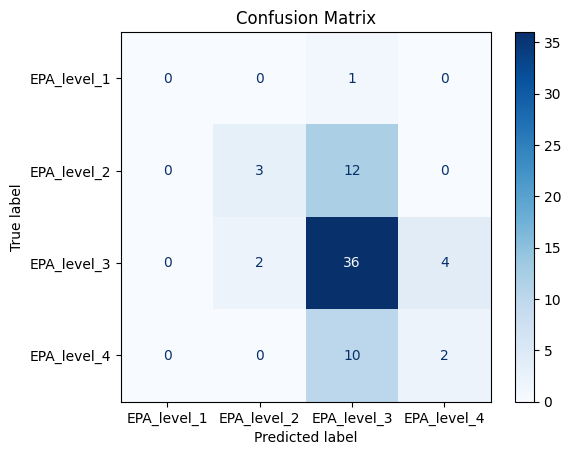

In [21]:
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=sqrt, n_e

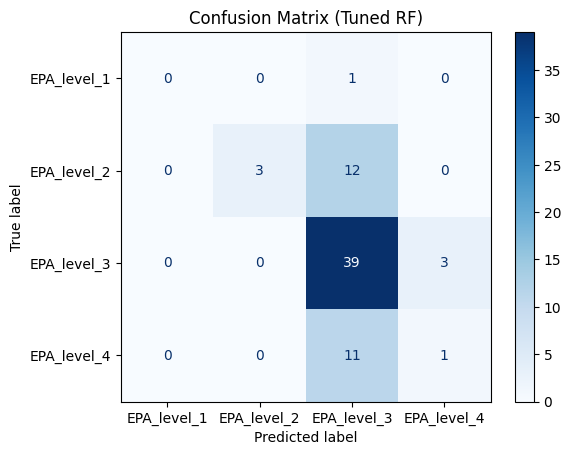

In [24]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=47)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Use macro F1 score for multi-class classification
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Use the best estimator to predict and evaluate
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Tuned RF)")
plt.show()


In [ ]:
# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
Best cross-validation accuracy: 0.6065584415584415


Do the hyperparameter search with F1 score due to imbalance in the data causign inflated accuracy. 
Consider 1 union 2 


### Binary classifcation problem

We can make this a binary classfication problem and mitigate some of the imbalance issues that we saw if we remove the EPA level 3 and combine levels 1 and 2. Is this a reasonable think to do form a chemistry standpoint?

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^

[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.2s


/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^

[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=300; total time=   0.4s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s


...

[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max

/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^

[CV] END ..max_depth=30, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s


/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dlipsey/iterativennsimple/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^

[CV] END ..max_depth=30, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=300; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=300; total time=   0.2s


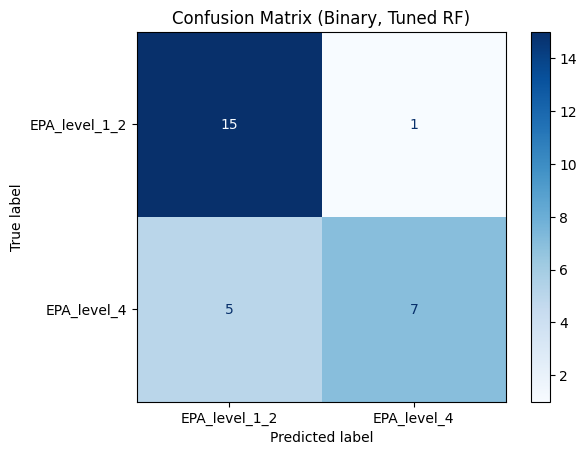

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best cross-validation F1: nan


In [ ]:
# Combine EPA_level_1 and EPA_level_2 into EPA_level_1_2, remove EPA_level_3, keep only EPA_level_1_2 and EPA_level_4

df = ChemNet_df2_epalevels.copy()

# Create new binary label
def combine_epa_levels(row):
    if row['EPA_level_1'] == 1 or row['EPA_level_2'] == 1:
        return 'EPA_level_1_2'
    elif row['EPA_level_4'] == 1:
        return 'EPA_level_4'
    else:
        return None  # EPA_level_3 or anything else

df['EPA_binary'] = df.apply(combine_epa_levels, axis=1)

# Filter out rows that are not EPA_level_1_2 or EPA_level_4
df_bin = df[df['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

# Prepare features and labels
embedding_cols = [col for col in df_bin.columns if col not in ['SMILES', 'EPA_binary'] + [col for col in df_bin.columns if col.startswith('EPA_level_')]]
X_bin = df_bin[embedding_cols]
y_bin = df_bin['EPA_binary']

# Train/test split
from sklearn.model_selection import train_test_split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# Set up Random Forest and GridSearchCV for binary classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

rf_bin = RandomForestClassifier(random_state=47)

grid_search_bin = GridSearchCV(
    estimator=rf_bin,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # binary F1
    n_jobs=-1,
    verbose=2
)

grid_search_bin.fit(X_train_bin, y_train_bin)

# Predict and evaluate
best_rf_bin = grid_search_bin.best_estimator_
y_pred_bin = best_rf_bin.predict(X_test_bin)


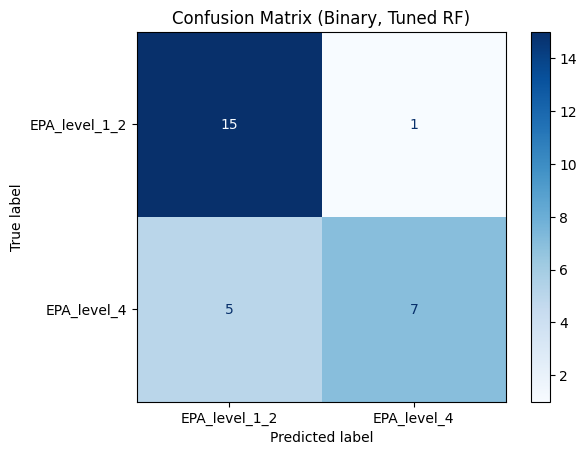

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best cross-validation F1: nan


In [26]:

# Confusion matrix for binary classification
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Binary, Tuned RF)")
plt.show()

print("Best parameters:", grid_search_bin.best_params_)
print("Best cross-validation F1:", grid_search_bin.best_score_)